In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, learning_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)
import joblib
import os
import time

# Load splits
X_train = pd.read_csv(r'..\Data\Splits\X_train.csv')
y_train = pd.read_csv(r'..\Data\Splits\y_train.csv').squeeze().values
X_test  = pd.read_csv(r'..\Data\Splits\X_test.csv')
y_test  = pd.read_csv(r'..\Data\Splits\y_test.csv').squeeze().values

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class distribution:", pd.Series(y_train).value_counts().to_dict())

Train shape: (12800, 8) Test shape: (2001, 8)
Train class distribution: {1: 6400, 0: 6400}


In [2]:
xgb_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.1, 0.5, 1],
    "reg_lambda": [1, 1.5, 2, 5]
}

search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=30,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

print("Starting hyperparameter search...")
start_time = time.time()
search.fit(X_train, y_train)
print(f"Search completed in {time.time()-start_time:.2f} seconds")

print("\nBest parameters:", search.best_params_)
print("Best cross-validation F1 score: {:.4f}".format(search.best_score_))

Starting hyperparameter search...
Fitting 3 folds for each of 30 candidates, totalling 90 fits


C:\Users\Arosha IIT\OneDrive - Robert Gordon University\Desktop\Private\TrafficSense AI\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:49:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Search completed in 8.97 seconds

Best parameters: {'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best cross-validation F1 score: 0.9859


In [3]:
# Baseline XGBoost (default parameters from previous notebook)
baseline_model = xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

# Tuned model
tuned_model = search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)
y_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]

# Metrics comparison
def get_metrics(y_true, y_pred, y_proba=None):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    }
    if y_proba is not None:
        metrics["ROC AUC"] = roc_auc_score(y_true, y_proba)
    return metrics

baseline_metrics = get_metrics(y_test, y_pred_baseline, y_proba_baseline)
tuned_metrics = get_metrics(y_test, y_pred_tuned, y_proba_tuned)

comparison_df = pd.DataFrame([baseline_metrics, tuned_metrics], index=["Baseline XGBoost", "Tuned XGBoost"])
print("=== Test Set Performance ===")
print(comparison_df.round(4))

=== Test Set Performance ===
                  Accuracy  Precision  Recall      F1  ROC AUC
Baseline XGBoost     0.980     0.9207  0.9850  0.9518   0.9972
Tuned XGBoost        0.981     0.9153  0.9975  0.9547   0.9971


C:\Users\Arosha IIT\OneDrive - Robert Gordon University\Desktop\Private\TrafficSense AI\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:49:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [4]:
y_train_pred_tuned = tuned_model.predict(X_train)
train_f1 = f1_score(y_train, y_train_pred_tuned)
test_f1 = f1_score(y_test, y_pred_tuned)
overfit_gap = train_f1 - test_f1

print(f"Training F1: {train_f1:.4f}")
print(f"Test F1:     {test_f1:.4f}")
print(f"Overfit gap (Train - Test): {overfit_gap:.4f}")
if overfit_gap > 0.05:
    print("⚠️  Moderate overfitting detected – consider more regularization or early stopping.")
else:
    print("✅ Model generalises well.")

Training F1: 0.9893
Test F1:     0.9547
Overfit gap (Train - Test): 0.0347
✅ Model generalises well.


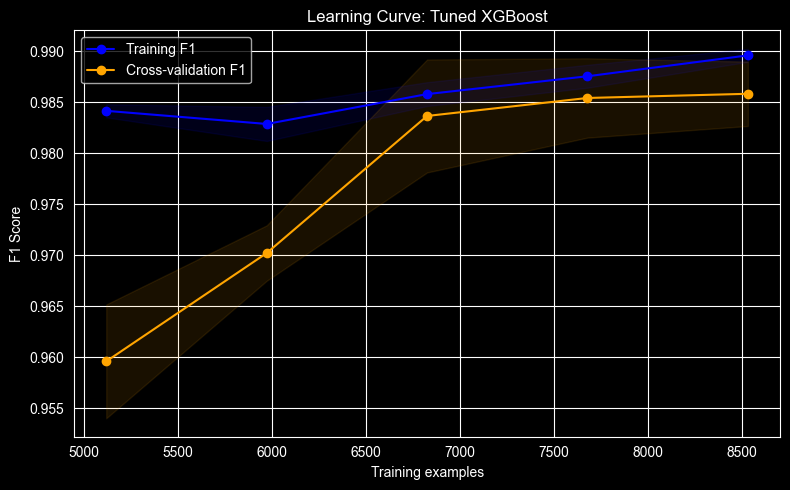

In [5]:
def plot_learning_curve(model, X, y, model_name, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='f1', n_jobs=-1
    )
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8,5))
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training F1')
    plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-validation F1')
    plt.title(f'Learning Curve: {model_name}')
    plt.xlabel('Training examples')
    plt.ylabel('F1 Score')
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_learning_curve(tuned_model, X_train, y_train, "Tuned XGBoost", cv=3)

C:\Users\Arosha IIT\OneDrive - Robert Gordon University\Desktop\Private\TrafficSense AI\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:49:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


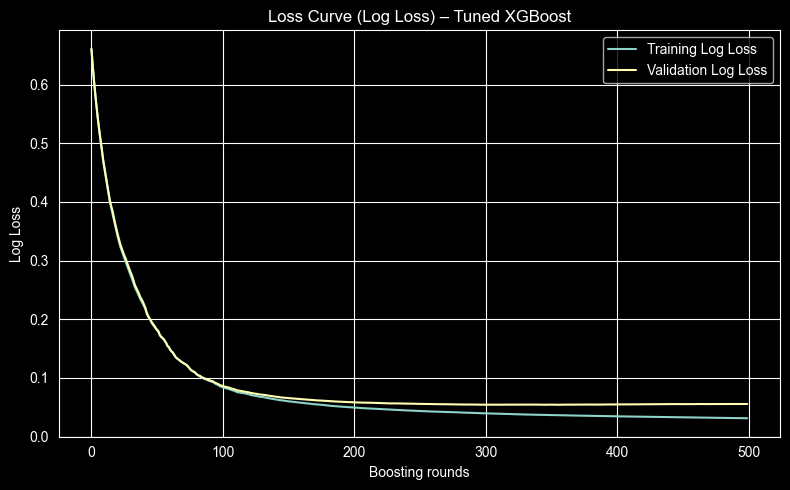

In [6]:
# Fit tuned model with eval set to get loss history
eval_set = [(X_train, y_train), (X_test, y_test)]
tuned_model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

results = tuned_model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(8,5))
plt.plot(x_axis, results['validation_0']['logloss'], label='Training Log Loss')
plt.plot(x_axis, results['validation_1']['logloss'], label='Validation Log Loss')
plt.title('Loss Curve (Log Loss) – Tuned XGBoost')
plt.xlabel('Boosting rounds')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

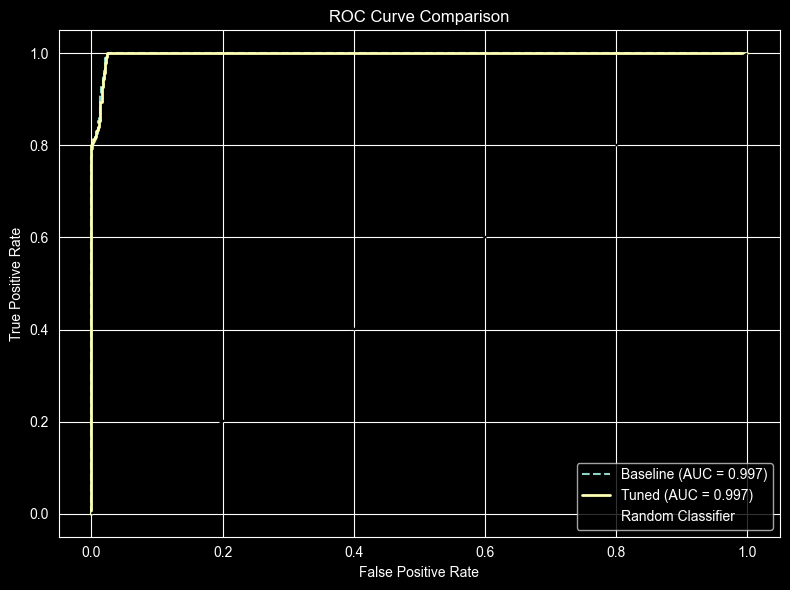

In [7]:
plt.figure(figsize=(8,6))
fpr_baseline, tpr_baseline, _ = roc_curve(y_test, y_proba_baseline)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_proba_tuned)

plt.plot(fpr_baseline, tpr_baseline, label=f'Baseline (AUC = {baseline_metrics["ROC AUC"]:.3f})', linestyle='--')
plt.plot(fpr_tuned, tpr_tuned, label=f'Tuned (AUC = {tuned_metrics["ROC AUC"]:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

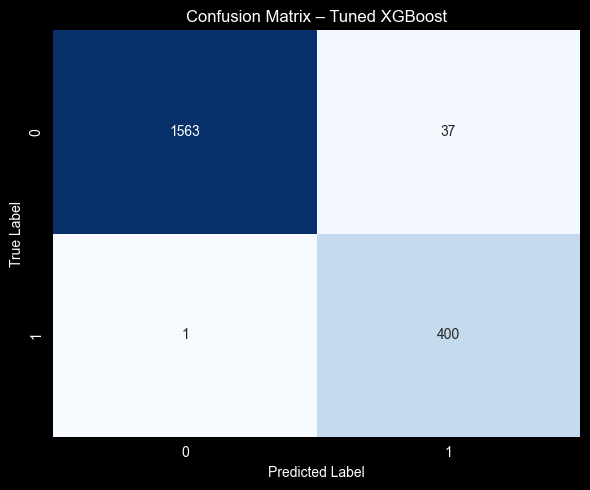


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1600
           1       0.92      1.00      0.95       401

    accuracy                           0.98      2001
   macro avg       0.96      0.99      0.97      2001
weighted avg       0.98      0.98      0.98      2001



In [8]:
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix – Tuned XGBoost')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

os.makedirs(r'..\Models\Tuned_Models', exist_ok=True)
model_path = r'..\Models\Tuned_Models\xgboost_tuned.pkl'
joblib.dump(tuned_model, model_path)
print(f"✅ Tuned XGBoost model saved to {model_path}")

